In [2]:
# ============================================================
# NIDS - ML Analysis Notebook
# Author: Sunishka Singh
# Description: End-to-end NIDS pipeline with live output
# ============================================================

import sys
import os

# Fix paths
os.chdir('C:/Users/sunis/ML-Network-Intrusion-Detection/ML-Network-Intrusion-Detection')
sys.path.insert(0, 'src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from preprocess import load_data, preprocess

# Load dataset
train, test = load_data()
X_train, X_test, y_train, y_test = preprocess(train, test)

print("✅ Dataset loaded and preprocessed successfully!")
print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")
print(f"\nAttack distribution in training set:")
print(y_train.value_counts())

[*] Loading dataset...
    Train shape: (125973, 43)
    Test shape : (22544, 43)
[*] Preprocessing...
    Scaler saved to models/scaler.pkl
    Classes: ['dos', 'normal', 'probe', 'r2l', 'u2r']
[+] Preprocessing complete.
✅ Dataset loaded and preprocessed successfully!

Training samples : 125973
Test samples     : 22544
Features         : 41

Attack distribution in training set:
label
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64


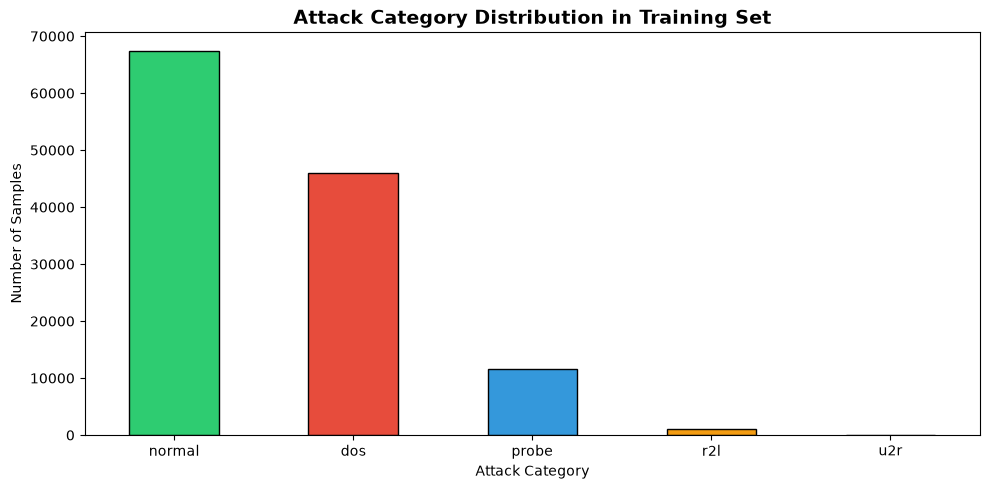

✅ Attack distribution chart saved to results/


In [3]:
# ── Cell 2: Attack Distribution Chart ─────────────────────────
plt.figure(figsize=(10, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6']
y_train.value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Attack Category Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('Attack Category')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('results/attack_distribution.png', dpi=150)
plt.show()
print("✅ Attack distribution chart saved to results/")

In [4]:
# ── Cell 3: Train Models ───────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import joblib

# Train Random Forest
print("[*] Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"✅ Random Forest Accuracy: {rf_acc*100:.2f}%")

# Train SVM
print("\n[*] Training SVM (may take a few minutes)...")
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
print(f"✅ SVM Accuracy: {svm_acc*100:.2f}%")

print(f"\n{'='*40}")
print(f"  Random Forest : {rf_acc*100:.2f}%")
print(f"  SVM           : {svm_acc*100:.2f}%")
print(f"  Best Model    : {'SVM' if svm_acc > rf_acc else 'Random Forest'}")
print(f"{'='*40}")

[*] Training Random Forest...
✅ Random Forest Accuracy: 74.06%

[*] Training SVM (may take a few minutes)...
✅ SVM Accuracy: 76.02%

  Random Forest : 74.06%
  SVM           : 76.02%
  Best Model    : SVM


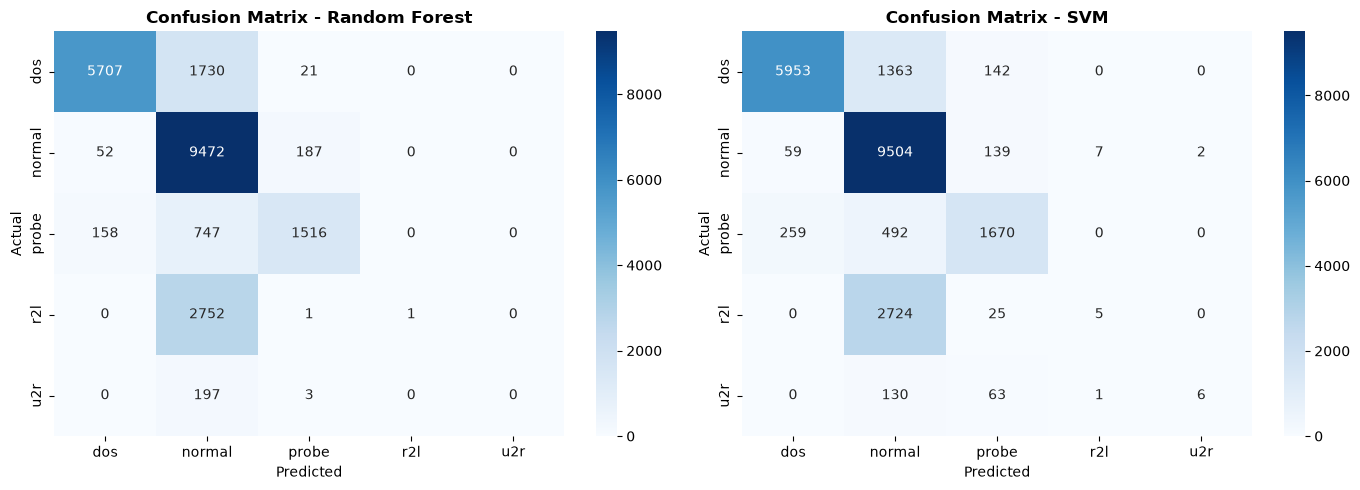

✅ Combined confusion matrix saved to results/


In [5]:
# ── Cell 4: Confusion Matrices ─────────────────────────────────
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = sorted(y_test.unique())

for ax, pred, title in zip(axes,
                           [rf_pred, svm_pred],
                           ['Random Forest', 'SVM']):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'Confusion Matrix - {title}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('results/confusion_matrices_combined.png', dpi=150)
plt.show()
print("✅ Combined confusion matrix saved to results/")